<div style="background:linear-gradient(135deg,#78350f 0%,#d97706 55%,#f59e0b 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fde68a;font-weight:700;text-transform:uppercase">Chapter 48 · Case Study</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">E-commerce Conversions: the Bernoulli Trial 🛒</div>
  <div style="font-size:15px;color:#fff7ed;max-width:740px;line-height:1.6">Every web session is a single yes/no experiment: add to cart, or not. This is the Bernoulli distribution in the wild. We find the baseline conversion rate p, model it, break it down by device, and simulate when the next purchase will arrive.</div>
  <div style="margin-top:16px;font-size:13px;color:#fed7aa">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup &amp; data

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
AMBER="#d97706"; TEAL="#0d9488"; INK="#1a2138"; GRID="#e6e9f2"; PINK="#db2777"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
try:    df = pd.read_csv("../../data/ecommerce_session_logs.csv")
except FileNotFoundError: df = pd.read_csv(BASE+"ecommerce_session_logs.csv")
print("loaded:", df.shape)
df.head()

loaded: (1000, 5)


,session_id,timestamp,user_id,device_type,cart_addition
0,SESS_10000,2026-01-01 00:38:00,USR_22081,Desktop,0
1,SESS_10001,2026-01-01 01:06:00,USR_23419,Desktop,1
2,SESS_10002,2026-01-01 00:58:00,USR_21574,Mobile,0
3,SESS_10003,2026-01-01 00:59:00,USR_20249,Mobile,0
4,SESS_10004,2026-01-01 01:42:00,USR_20673,Mobile,0


<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 1 · THE BASELINE RATE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">One number that runs the business</div>
<div style="color:#4a5578;margin-top:6px">A Bernoulli trial has two outcomes with probabilities p and 1-p. Here the trial is a session and the success is cart_addition = 1. The single parameter p is the conversion rate.</div>
</div>

In [2]:
x = df["cart_addition"]
p = x.mean()
print(f"sessions          : {len(x):,}")
print(f"add-to-cart events : {int(x.sum()):,}")
print(f"baseline rate p    : {p:.4f}  ({p:.1%})")
print(f"Bernoulli mean  = p        = {p:.4f}")
print(f"Bernoulli variance = p(1-p) = {p*(1-p):.4f}")
print(f"std dev = sqrt(p(1-p))      = {np.sqrt(p*(1-p)):.4f}")

sessions          : 1,000
add-to-cart events : 148
baseline rate p    : 0.1480  (14.8%)
Bernoulli mean  = p        = 0.1480
Bernoulli variance = p(1-p) = 0.1261
std dev = sqrt(p(1-p))      = 0.3551


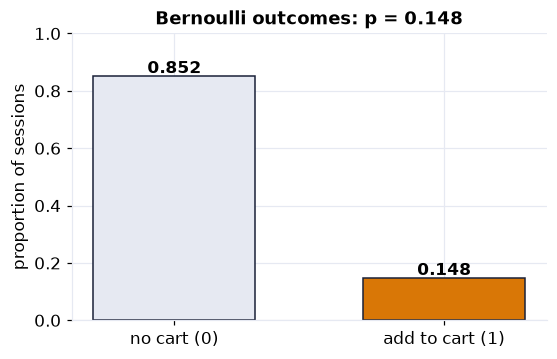

In [3]:
fig,ax=plt.subplots(figsize=(5.2,3.4))
obs=[(x==0).mean(),(x==1).mean()]
ax.bar([0,1],obs,color=[GRID,AMBER],edgecolor=INK,width=0.6)
for i,v in enumerate(obs): ax.text(i,v+0.01,f"{v:.3f}",ha="center",fontweight="bold")
ax.set_xticks([0,1],["no cart (0)","add to cart (1)"]); ax.set_ylim(0,1)
ax.set_ylabel("proportion of sessions"); ax.set_title(f"Bernoulli outcomes: p = {p:.3f}")
plt.tight_layout(); plt.show()

The whole distribution is two bars: about **85%** of sessions add nothing, **15%** convert. That single rate p is the heartbeat of the funnel, and its variance p(1&minus;p) is largest when p is near 0.5 and small when conversions are rare, as here.

<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 2 · BREAK IT DOWN BY DEVICE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Is the trial the same everywhere?</div>
<div style="color:#4a5578;margin-top:6px">A Bernoulli rate can hide segments. Splitting p by device shows whether mobile, desktop, and tablet visitors convert at different rates, the first question any analyst asks.</div>
</div>

In [4]:
by_dev = df.groupby("device_type")["cart_addition"].agg(["mean","count"]).sort_values("mean",ascending=False)
by_dev.columns=["conversion_rate","sessions"]
print(by_dev.round(4))

             conversion_rate  sessions
device_type                           
Tablet                0.2381        84
Mobile                0.1398       608
Desktop               0.1396       308


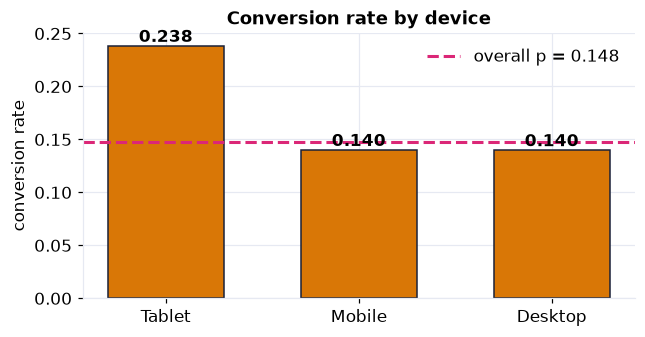

In [5]:
fig,ax=plt.subplots(figsize=(6,3.2))
ax.bar(by_dev.index, by_dev["conversion_rate"], color=AMBER, edgecolor=INK, width=0.6)
ax.axhline(p, color=PINK, ls="--", lw=2, label=f"overall p = {p:.3f}")
for i,(r) in enumerate(by_dev["conversion_rate"]): ax.text(i,r+0.004,f"{r:.3f}",ha="center",fontweight="bold")
ax.set_ylabel("conversion rate"); ax.set_title("Conversion rate by device"); ax.legend()
plt.tight_layout(); plt.show()

Each device is its own Bernoulli process with its own p. Wherever a segment sits clearly above or below the dashed overall rate, that is a lever: the business can chase the gap. (These are still just estimates, Chapter 59 shows how to test whether such differences are real.)

<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 3 · WHEN WILL THE NEXT PURCHASE ARRIVE?</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Bernoulli trials become a waiting game</div>
<div style="color:#4a5578;margin-top:6px">Stream sessions one after another, each a Bernoulli(p) trial. The number of sessions until the next add-to-cart follows the GEOMETRIC distribution, with mean 1/p. We simulate it.</div>
</div>

In [6]:
rng = np.random.default_rng(48)
# simulate a long stream of sessions; record the gap (in sessions) between conversions
stream = rng.random(2_000_000) < p
idx = np.flatnonzero(stream)
gaps = np.diff(idx)                      # sessions between consecutive conversions
print(f"simulated mean gap = {gaps.mean():.2f} sessions   (theory 1/p = {1/p:.2f})")
print(f"P(next conversion within 5 sessions) = {1-(1-p)**5:.3f}")
print(f"P(next conversion within 10 sessions) = {1-(1-p)**10:.3f}")

simulated mean gap = 6.76 sessions   (theory 1/p = 6.76)
P(next conversion within 5 sessions) = 0.551
P(next conversion within 10 sessions) = 0.798


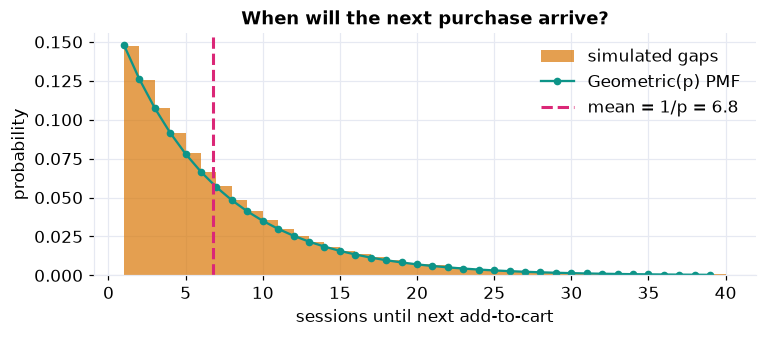

In [7]:
fig,ax=plt.subplots(figsize=(7,3.2))
kmax=40; ax.hist(gaps,bins=np.arange(1,kmax+1),density=True,color=AMBER,alpha=0.7,label="simulated gaps")
k=np.arange(1,kmax); ax.plot(k, stats.geom.pmf(k,p),"o-",color=TEAL,ms=4,label="Geometric(p) PMF")
ax.axvline(1/p,color=PINK,ls="--",lw=2,label=f"mean = 1/p = {1/p:.1f}")
ax.set_xlabel("sessions until next add-to-cart"); ax.set_ylabel("probability"); ax.set_title("When will the next purchase arrive?"); ax.legend()
plt.tight_layout(); plt.show()

The simulated waiting times trace the geometric PMF exactly, with an average wait of about **7 sessions** between conversions. The business can now answer "how long until the next sale?" probabilistically: there is a **55%** chance within 5 sessions and a **80%** chance within 10. Bernoulli trials, stacked in time, became a forecast.

<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 4 · SCALING UP TO A DAY</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">From one trial to a daily total</div>
<div style="color:#4a5578;margin-top:6px">Add up n independent Bernoulli trials and you get a BINOMIAL count. A day of n sessions yields Binomial(n, p) conversions, whose total is, by the CLT, approximately normal.</div>
</div>

In [8]:
n_day = 200
expected = n_day*p
print(f"in a day of {n_day} sessions: expected conversions = n*p = {expected:.1f}")
print(f"std dev = sqrt(n p (1-p)) = {np.sqrt(n_day*p*(1-p)):.2f}")
sim_days = rng.binomial(n_day, p, size=100_000)
print(f"simulated daily mean = {sim_days.mean():.1f}, P(>=40 conversions) = {(sim_days>=40).mean():.3f}")

in a day of 200 sessions: expected conversions = n*p = 29.6
std dev = sqrt(n p (1-p)) = 5.02


simulated daily mean = 29.6, P(>=40 conversions) = 0.028


A single yes/no trial scales all the way up: one session is Bernoulli, a fixed batch of them is binomial, and a long run of daily totals is approximately normal (the Central Limit Theorem, Chapter 57). The same p that described one click now forecasts the whole day, with an expected **30 conversions** per 200 sessions.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ Case closed</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">A web session is the textbook Bernoulli trial. We estimated its rate p = 0.148, modeled its mean and variance, segmented it by device, simulated the geometric waiting time to the next purchase, and scaled it to a binomial daily total. One parameter, the whole conversion story.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>